In [10]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [11]:
X_train = np.load("../models/X_train_bert.npy")
X_test = np.load("../models/X_test_bert.npy")

df = pd.read_csv("../data/fake_jobs_cleaned.csv")

# Targets
y = df['fraudulent']

# Need same split as Notebook 2
from sklearn.model_selection import train_test_split

X_dummy = df['clean_text']  # Only used to replicate splitting

_, _, y_train, y_test = train_test_split(
    X_dummy, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("\n----------------------------")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()


----------------------------
Accuracy: 0.8907753254102999
Precision: 0.2815126050420168
Recall: 0.7528089887640449
F1 Score: 0.40978593272171254

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1678
           1       0.28      0.75      0.41        89

    accuracy                           0.89      1767
   macro avg       0.63      0.83      0.67      1767
weighted avg       0.95      0.89      0.91      1767



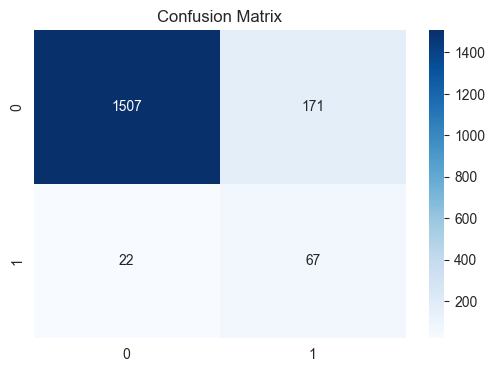

['../models/bert_logistic_regression.pkl']

In [13]:
#Model 1 — Logistic Regression (BEST baseline for BERT)

log_reg = LogisticRegression(max_iter=2000, class_weight="balanced")
log_reg.fit(X_train, y_train)

evaluate_model(log_reg, X_test, y_test)

joblib.dump(log_reg, "../models/bert_logistic_regression.pkl")


----------------------------
Accuracy: 0.9688737973967176
Precision: 0.6847826086956522
Recall: 0.7078651685393258
F1 Score: 0.6961325966850829

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1678
           1       0.68      0.71      0.70        89

    accuracy                           0.97      1767
   macro avg       0.83      0.85      0.84      1767
weighted avg       0.97      0.97      0.97      1767



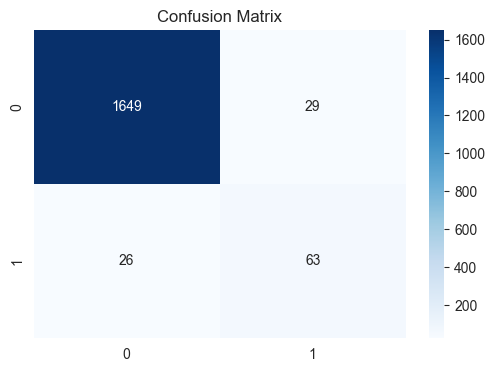

['../models/bert_svm.pkl']

In [14]:
#Model 2 — SVM (RBF Kernel performs well on BERT)
svm = SVC(kernel="rbf", class_weight="balanced", probability=True)
svm.fit(X_train, y_train)

evaluate_model(svm, X_test, y_test)

joblib.dump(svm, "../models/bert_svm.pkl")


----------------------------
Accuracy: 0.9722693831352575
Precision: 0.9166666666666666
Recall: 0.4943820224719101
F1 Score: 0.6423357664233577

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1678
           1       0.92      0.49      0.64        89

    accuracy                           0.97      1767
   macro avg       0.95      0.75      0.81      1767
weighted avg       0.97      0.97      0.97      1767



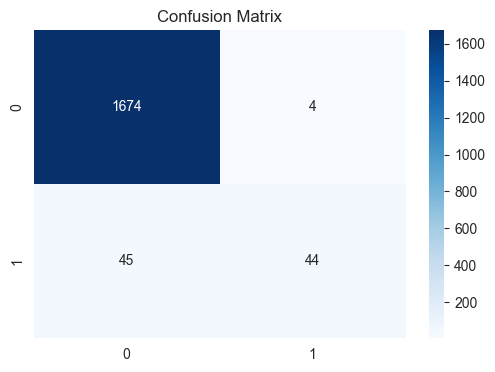

['../models/bert_xgboost.pkl']

In [15]:
#Model 3 — XGBoost (Very powerful for BERT vectors)
xgb = XGBClassifier(
    eval_metric="logloss",
    learning_rate=0.05,
    n_estimators=300,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10   # because dataset is imbalanced
)

xgb.fit(X_train, y_train)
evaluate_model(xgb, X_test, y_test)

joblib.dump(xgb, "../models/bert_xgboost.pkl")


----------------------------
Accuracy: 0.9683078664402943
Precision: 1.0
Recall: 0.3707865168539326
F1 Score: 0.5409836065573771

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1678
           1       1.00      0.37      0.54        89

    accuracy                           0.97      1767
   macro avg       0.98      0.69      0.76      1767
weighted avg       0.97      0.97      0.96      1767



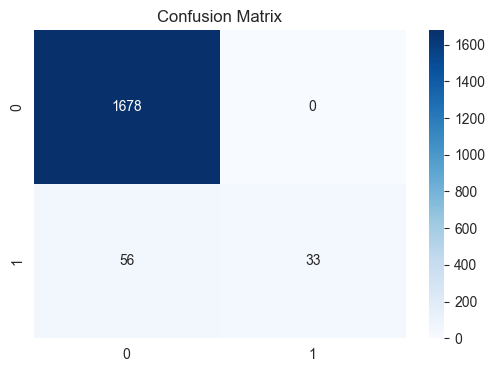

['../models/bert_random_forest.pkl']

In [16]:
#Model 4 — RandomForest (Works but not optimal)
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
evaluate_model(rf, X_test, y_test)

joblib.dump(rf, "../models/bert_random_forest.pkl")

In [17]:
#Compare All Models

models = {
    "LogReg": log_reg,
    "SVM": svm,
    "RandomForest": rf,
    "XGBoost": xgb
}

scores = []

for name, model in models.items():
    pred = model.predict(X_test)
    scores.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

pd.DataFrame(scores, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

,Model,Accuracy,Precision,Recall,F1 Score
0,LogReg,0.890775,0.281513,0.752809,0.409786
1,SVM,0.968874,0.684783,0.707865,0.696133
2,RandomForest,0.968308,1.000000,0.370787,0.540984
3,XGBoost,0.972269,0.916667,0.494382,0.642336


In [18]:
best_model = svm
joblib.dump(best_model, "../models/best_bert_model.pkl")
print("Best BERT model saved!")

Best BERT model saved!
